# Flexible Job Shop — the complete v0.1.0 pipeline in one notebook

This is the **final Tier 3 tutorial** and deliberately exercises every major v0.1.0 subsystem against a single deterministic instance. Nothing in this notebook is approximate — every number is pinned in `tests/integration/test_flexible_job_shop.py` and regenerated top-to-bottom on every run.

The classic **Flexible Job Shop Scheduling Problem** (FJSSP) lets each operation run on one of several eligible machines with different processing times. LangGOAP's CP-SAT scheduler does not model per-machine mutex natively (there is no `NoOverlap` resource), so the FJSSP "choose a machine" decision is recast here as a **"choose a mode"** decision on each operation: `express` runs on an in-house fast machine that is pricey per hour; `standard` runs on a cloud worker that is cheap but slow. This is the same recasting that `project_job_scheduling.ipynb` uses for MRCPSP, and it is the idiomatic LangGOAP pattern for flexibility problems.

What you will see working together:

1. **A\*** finds the greedy-by-cost plan (all `*_express` modes).
2. **CSP validation** rejects the greedy plan under a `cost_usd=130` hard cap, triggering the pipeline's enumeration path.
3. **CSP enumeration + multi-plan optimization** picks the cheapest single-blacklist alternative via CP-SAT Boolean selection variables with a `cost_usd → MINIMIZE` objective.
4. **CSP temporal scheduling** places three independent jobs on parallel tracks with per-job precedence chains, giving a makespan dominated by the critical-path job (`gamma`).
5. **Hard / soft / infeasible score decomposition** across three goal variants (no cap, impossible cap, soft cap).
6. **Fluent `ConstraintBuilder`** reproduces the hand-rolled goal structurally — the `ConstraintProvider` analogue.
7. **`GoapGraph` tracer + `StoreExecutionHistory`** capture the planning telemetry and persist an `ExecutionRecord` in a LangGraph `InMemoryStore`.
8. **`render_ascii_gantt`** draws the resulting schedule straight from `CSPMetadata.schedule`.

## 1. The flexible job shop domain

The instance is deliberately small: **3 jobs** (`alpha`, `beta`, `gamma`), each with **2 sequential operations** (`prepare → finalize`), each with **2 modes** (`express`, `standard`). That gives `3 × 2 × 2 = 12` actions total — a tiny catalog the CSP solver dispatches in milliseconds and every number in this notebook can be checked by hand.

Every action aggregates two resources: `cost_usd` (the CSP constraint and objective) and `duration_hours` (informational). Every action also carries a `datetime.timedelta` duration that feeds CP-SAT's temporal scheduler.

In [1]:
from tutorial_examples.data.flexible_job_shop_instance import (
    ALT_PLAN_COST_USD,
    ALT_PLAN_DURATION_HOURS,
    GREEDY_COST_USD,
    GREEDY_DURATION_HOURS,
    GREEDY_MAKESPAN_HOURS,
    HARD_COST_CAP,
    JOBS,
)
from tutorial_examples.flexible_job_shop import (
    flexible_job_shop_actions,
    flexible_job_shop_goal,
    flexible_job_shop_goal_fluent,
    flexible_job_shop_start,
)

actions = flexible_job_shop_actions()
start = flexible_job_shop_start()

print(f"jobs            : {[j.name for j in JOBS]}")
print(f"total actions   : {len(actions)}")
print(f"state flags     : {len(start)}")
print()
print(f"{'action':<26}{'dur':<6}{'cost_usd':<10}preconditions")
print("-" * 86)
for a in actions:
    dur = f"{int(a.duration.total_seconds() / 3600)}h" if a.duration else "-"
    cost_usd = a.resources["cost_usd"]
    pre = ", ".join(f"{k}={v}" for k, v in a.preconditions.items()) or "(none)"
    print(f"{a.name:<26}{dur:<6}{cost_usd:<10}{pre}")

jobs            : ['alpha', 'beta', 'gamma']
total actions   : 12
state flags     : 6

action                    dur   cost_usd  preconditions
--------------------------------------------------------------------------------------
prepare_alpha_express     2h    20.0      prepare_alpha_done=False
prepare_alpha_standard    4h    8.0       prepare_alpha_done=False
finalize_alpha_express    1h    10.0      finalize_alpha_done=False, prepare_alpha_done=True
finalize_alpha_standard   2h    4.0       finalize_alpha_done=False, prepare_alpha_done=True
prepare_beta_express      3h    30.0      prepare_beta_done=False
prepare_beta_standard     5h    12.0      prepare_beta_done=False
finalize_beta_express     2h    20.0      finalize_beta_done=False, prepare_beta_done=True
finalize_beta_standard    3h    8.0       finalize_beta_done=False, prepare_beta_done=True
prepare_gamma_express     4h    40.0      prepare_gamma_done=False
prepare_gamma_standard    6h    15.0      prepare_gamma_done=False
fi

### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

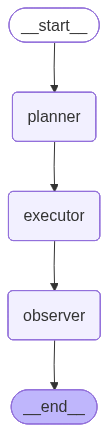

In [2]:
from IPython.display import Image, display

from langgoap import GoapGraph

graph = GoapGraph(actions=actions)
display(Image(graph.compile().get_graph().draw_mermaid_png()))

Two design choices make this a clean showcase:

- **`prepare_*` actions have no prior-op guards** — the three jobs are mutually independent, so the scheduler is free to run them in parallel.
- **`finalize_*_*` requires the matching `prepare_*_done`** — this encodes the per-job precedence chain as a plain precondition. The scheduler picks this up automatically via effect→precondition matching in `planner/csp.py::build_dependency_graph`.

## 2. Greedy plan via the A\* → CSP pipeline

The A\* heuristic minimizes the sum of `Mode.cost` (wall-clock hours), so the greedy plan picks every `*_express` mode. With no cost cap on the goal, CSP still runs because the goal carries a `cost_usd → MINIMIZE` objective — that is what routes the plan through the scheduler and populates `plan.metadata.csp`.

In [3]:
from langgoap import pipeline_plan
from langgoap.state import PlanningState

greedy = pipeline_plan(
    PlanningState.from_dict(start),
    flexible_job_shop_goal(),
    actions,
)
assert greedy is not None

print(f"action_names : {greedy.action_names}")
print(f"total_cost   : {greedy.total_cost}")
print(f"score        : {greedy.score}")

action_names : ['prepare_alpha_express', 'finalize_alpha_express', 'prepare_beta_express', 'finalize_beta_express', 'prepare_gamma_express', 'finalize_gamma_express']
total_cost   : 15.0
score        : HardSoftScore(hard=0, soft=-150)


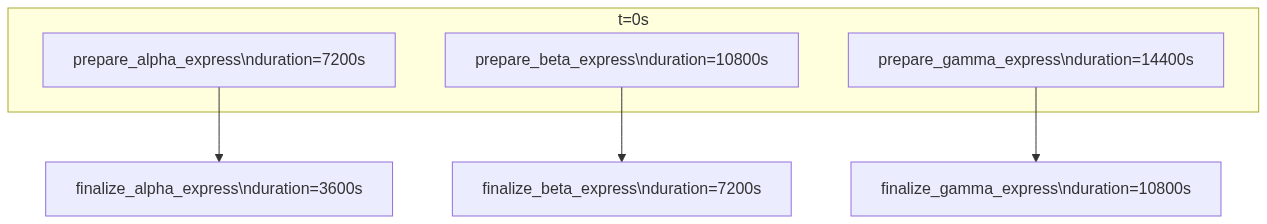

In [4]:
from langchain_core.runnables.graph_mermaid import draw_mermaid_png as _draw_png
from langgoap.viz.mermaid import render_mermaid

display(Image(_draw_png(render_mermaid(greedy))))

Six actions, one per operation per job, all in `*_express` mode. The A\* total cost is `15.0` (`2+1+3+2+4+3`), and the `HardSoftScore` is `hard=0.0, soft=-150.0` — the plan is feasible and the soft component reflects the MINIMIZE objective summing to `cost_usd = 150`.

## 3. Schedule — three jobs in parallel, gamma on the critical path

CP-SAT's temporal scheduler turns every `ActionSpec.duration` into an `IntervalVar` and seeds precedence edges from the dependency graph. Because the three jobs share no preconditions, all three `prepare_*_express` actions start at `t=0` and run in parallel. Each job's `finalize_*` waits only for its own prepare, so the makespan is the maximum per-job duration:

| Job   | Prepare (express) | Finalize (express) | Per-job duration |
|-------|-------------------|--------------------|------------------|
| alpha | 2h                | 1h                 | **3h**           |
| beta  | 3h                | 2h                 | **5h**           |
| gamma | 4h                | 3h                 | **7h**  ← critical path |

Serial execution would take `15h`; parallelism collapses the wall-clock time to `7h`.

In [5]:
from datetime import timedelta

csp = greedy.metadata.csp
assert csp is not None

print(f"status   : {csp.status.value}")
print(f"makespan : {csp.makespan}")
print()
print(f"{'action':<26}{'start':>10}{'end':>10}")
print("-" * 46)
for entry in sorted(csp.schedule, key=lambda s: (s.start, s.action_name)):
    print(f"{entry.action_name:<26}{str(entry.start):>10}{str(entry.end):>10}")

assert csp.makespan == timedelta(hours=GREEDY_MAKESPAN_HOURS)

status   : feasible
makespan : 7:00:00

action                         start       end
----------------------------------------------
prepare_alpha_express        0:00:00   2:00:00
prepare_beta_express         0:00:00   3:00:00
prepare_gamma_express        0:00:00   4:00:00
finalize_gamma_express       4:00:00   7:00:00
finalize_beta_express        5:00:00   7:00:00
finalize_alpha_express       6:00:00   7:00:00


### ASCII Gantt

`render_ascii_gantt` draws the schedule straight from `CSPMetadata.schedule`. The three overlapping `prepare_*_express` bars at the top and the shifted `finalize_*_express` tails tell the whole parallelism story in one picture.

In [6]:
from langgoap.viz import render_ascii_gantt

print(render_ascii_gantt(greedy, width=60))

action                  |------------------------------------------------------------|  0..25200s
prepare_alpha_express   |#################                                           |  0-7200s
finalize_alpha_express  |                                                   #########|  21600-25200s
prepare_beta_express    |#########################                                   |  0-10800s
finalize_beta_express   |                                          ##################|  18000-25200s
prepare_gamma_express   |##################################                          |  0-14400s
finalize_gamma_express  |                                  ##########################|  14400-25200s



## 4. CSP enumeration under a hard `cost_usd` cap

Now attach a **hard** cost cap. The greedy plan aggregates `cost_usd = 150`, so a `cost_usd <= 130` hard constraint rejects it. `validate_plan()` marks the primary plan `INFEASIBLE`; the pipeline then calls `enumerate_alternatives()` which blacklists each action in the rejected plan one at a time and re-runs A\* for each. Every surviving alternative feeds `optimize_plans()`, which builds a single CP-SAT model with Boolean selection variables, applies the hard constraint, and minimizes the weighted objective.

The only single-blacklist alternative that:

- satisfies `cost_usd <= 130` (eliminates every express swap except `gamma`), **and**
- minimizes the `cost_usd → MINIMIZE` objective (beats every other feasible alternative),

is: blacklist `prepare_gamma_express` → use `prepare_gamma_standard`. That swap cuts `cost_usd` from `150 → 125` at the cost of one extra wall-clock hour on the `gamma` prepare (2 extra hours in duration, `40 → 15` USD).

In [7]:
capped_goal = flexible_job_shop_goal(
    max_cost_usd=HARD_COST_CAP, max_cost_level="hard"
)
capped = pipeline_plan(
    PlanningState.from_dict(start), capped_goal, actions
)
assert capped is not None
capped_csp = capped.metadata.csp
assert capped_csp is not None

print(f"action_names : {capped.action_names}")
print(f"status       : {capped_csp.status.value}")
print(f"total_cost   : {capped.total_cost}")
print(f"score        : {capped.score}")
print()
print("resource_usage:")
for usage in capped_csp.resource_usage:
    print(
        f"  {usage.key:<16} total={usage.total:<7}"
        f" level={usage.level:<4} satisfied={usage.satisfied}"
    )

assert "prepare_gamma_standard" in capped.action_names
assert "prepare_gamma_express" not in capped.action_names

action_names : ['prepare_alpha_express', 'finalize_alpha_express', 'prepare_beta_express', 'finalize_beta_express', 'prepare_gamma_standard', 'finalize_gamma_express']
status       : optimal
total_cost   : 16.0
score        : HardSoftScore(hard=0, soft=-125)

resource_usage:
  cost_usd         total=125.0   level=hard satisfied=True
  duration_hours   total=17.0    level=info satisfied=True


A few things to notice:

- **`status = optimal`** — multi-plan CP-SAT returns `OPTIMAL` when it has proved it found the minimum (it has), not just a feasible selection.
- **`makespan = None`** — `optimize_plans()` only *picks* the best plan; it does not also build an `IntervalVar` schedule. That is the job of `validate_plan()` on the primary plan path. For enumeration results, the schedule is left unset.
- **`cost_usd.level = 'hard'`** — the usage entry is stamped with the level of its matching `ConstraintSpec`. Since we declared `cost_usd` hard, it reads `hard` (not `info`).
- **`duration_hours.level = 'info'`** — no constraint was declared on `duration_hours`, so it stays `info`. A visualizer can render the two differently.
- **`soft = -125`** — the MINIMIZE objective now sums to `125` instead of `150`, and since MINIMIZE flips sign, the soft score reads `-125`. The plan strictly beats the greedy plan's `soft = -150`.

## 5. Score decomposition — infeasible and soft variants

The Score hierarchy uses a lexicographic hard/soft sign convention: `hard <= 0` (zero means feasible), and `soft` has no sign restriction (MINIMIZE contributions flip sign). This makes three cases easy to inspect at once:

| Variant           | Cap       | Hard  | Soft   | Feasible? |
|-------------------|-----------|-------|--------|-----------|
| no cap            | (none)    | `0`   | `-150` | ✓         |
| hard `$130` cap   | `130`     | `0`   | `-125` | ✓         |
| hard `$50` cap    | `50`      | `-100`| `-150` | ✗         |
| soft `$100` cap   | `100`     | `0`   | `-200` | ✓         |

The infeasible variant demonstrates what happens when **no** single-blacklist alternative rescues the plan: every alternative still violates the cap, so the pipeline returns the primary plan marked `INFEASIBLE` with a hard score equal to the violation amount. The soft variant demonstrates that a soft violation penalizes `soft` but leaves `hard == 0` and the plan still feasible — this is the hard/soft split introduced in Epic 3.

In [8]:
from langgoap import CSPStatus
from langgoap.score import HardSoftScore

# Infeasible hard cap — no alternative can satisfy it.
impossible = pipeline_plan(
    PlanningState.from_dict(start),
    flexible_job_shop_goal(max_cost_usd=50.0, max_cost_level="hard"),
    actions,
)
assert impossible is not None and impossible.metadata.csp is not None
assert impossible.metadata.csp.status == CSPStatus.INFEASIBLE
assert isinstance(impossible.score, HardSoftScore)
print(f"[infeasible hard cap=$50]")
print(f"  status    = {impossible.metadata.csp.status.value}")
print(f"  score     = {impossible.score}")
print(f"  feasible  = {impossible.score.is_feasible()}")
print()

# Soft cap — violation penalizes soft but plan stays feasible.
soft = pipeline_plan(
    PlanningState.from_dict(start),
    flexible_job_shop_goal(max_cost_usd=100.0, max_cost_level="soft"),
    actions,
)
assert soft is not None and soft.metadata.csp is not None
assert isinstance(soft.score, HardSoftScore)
print(f"[soft cap=$100]")
print(f"  status    = {soft.metadata.csp.status.value}")
print(f"  score     = {soft.score}")
print(f"  feasible  = {soft.score.is_feasible()}")
soft_cost = next(u for u in soft.metadata.csp.resource_usage if u.key == "cost_usd")
print(f"  cost_usd  = total={soft_cost.total} level={soft_cost.level} satisfied={soft_cost.satisfied}")

All alternative plans infeasible


[infeasible hard cap=$50]
  status    = infeasible
  score     = HardSoftScore(hard=-100, soft=-150)
  feasible  = False

[soft cap=$100]
  status    = feasible
  score     = HardSoftScore(hard=0, soft=-200)
  feasible  = True
  cost_usd  = total=150.0 level=soft satisfied=False


For the soft case the arithmetic is `soft = -objective(150) - overflow(150 - 100 = 50) = -200`. `cost_usd.satisfied` reads `False` but the plan itself stays `is_feasible() == True` because no **hard** constraint was violated.

## 6. Fluent `ConstraintBuilder` parity

The tutorial module ships two goal factories for the capped case: `flexible_job_shop_goal(max_cost_usd=...)` builds the `GoalSpec` by hand, and `flexible_job_shop_goal_fluent(...)` builds it via the `ConstraintBuilder` fluent API. Both produce structurally identical `GoalSpec` instances and — when run through the same pipeline — identical plans and scores. The builder is a fluent constraint-provider analogue: a *typed construction helper*, not a new field on `GoalSpec`.

In [9]:
hand_goal = flexible_job_shop_goal(
    max_cost_usd=HARD_COST_CAP, max_cost_level="hard"
)
fluent_goal = flexible_job_shop_goal_fluent(
    max_cost_usd=HARD_COST_CAP, max_cost_level="hard"
)

assert dict(hand_goal.conditions) == dict(fluent_goal.conditions)
assert hand_goal.constraints == fluent_goal.constraints
assert dict(hand_goal.objectives or {}) == dict(fluent_goal.objectives or {})
print("hand-rolled and fluent goals are structurally identical")
print()
print("fluent chain:")
print("    ConstraintBuilder.for_plan()")
print('        .sum_resource("cost_usd")')
print(f"        .bounded(max={HARD_COST_CAP})")
print('        .penalize(level="hard", weight=1.0)')
print('        .as_constraint("cost_usd")')
print()
print("    ConstraintBuilder.for_plan()")
print('        .sum_resource("cost_usd")')
print("        .minimize()")
print('        .as_objective("cost_usd")')

fluent_plan = pipeline_plan(PlanningState.from_dict(start), fluent_goal, actions)
assert fluent_plan is not None
assert set(fluent_plan.action_names) == set(capped.action_names)
assert fluent_plan.score == capped.score

hand-rolled and fluent goals are structurally identical

fluent chain:
    ConstraintBuilder.for_plan()
        .sum_resource("cost_usd")
        .bounded(max=130.0)
        .penalize(level="hard", weight=1.0)
        .as_constraint("cost_usd")

    ConstraintBuilder.for_plan()
        .sum_resource("cost_usd")
        .minimize()
        .as_objective("cost_usd")


## 7. Natural-language goal intake

`GoalInterpreter` turns a plain-English request into a `GoalSpec` by asking an LLM for a structured `InterpretedGoal` — the conditions, constraints, objectives, and a reasoning trace. Because the prompt is provider-agnostic (any `BaseChatModel`), this notebook uses `FakeStructuredModel` to pin the response and keep the run reproducible in CI; swap in `ChatOpenAI`, `ChatAnthropic`, or any other chat model to drive it from a real LLM.

The NL request below carries the same intent as the hand-rolled capped goal — *finish every job, cap at \$130, minimize cost* — so the interpreted goal should be structurally identical, and `GoapGraph.invoke_nl()` should run the exact same alternative plan we picked manually in §4.

In [10]:
from langgoap import (
    GoalInterpreter,
    GoapGraph,
    InterpretedConstraint,
    InterpretedGoal,
    InterpretedObjective,
)
from langgoap.testing import FakeStructuredModel

fake_goal = InterpretedGoal(
    conditions={
        "finalize_alpha_done": True,
        "finalize_beta_done": True,
        "finalize_gamma_done": True,
    },
    constraints=[
        InterpretedConstraint(
            key="cost_usd",
            max=HARD_COST_CAP,
            min=None,
            weight=1.0,
            level="hard",
        ),
    ],
    objectives=[
        InterpretedObjective(metric="cost_usd", direction="minimize"),
    ],
    reasoning="The user wants every job finished at the lowest cost under a $130 cap.",
)
nl_llm = FakeStructuredModel(response=fake_goal)

# Structural parity: the interpreted GoalSpec matches the hand-rolled capped goal.
interpreter = GoalInterpreter(llm=nl_llm, actions=actions)
nl_goal = interpreter.interpret(
    "Finish every job with cost_usd at or under $130 and minimize total cost."
)
assert dict(nl_goal.conditions) == dict(hand_goal.conditions)
assert nl_goal.constraints == hand_goal.constraints
assert dict(nl_goal.objectives or {}) == dict(hand_goal.objectives or {})
print("interpreted goal matches the hand-rolled capped goal")
print()

# One-liner: invoke_nl interprets + plans + executes in a single call.
nl_graph = GoapGraph(actions=actions)
nl_result = nl_graph.invoke_nl(
    "Finish every job with cost_usd at or under $130 and minimize total cost.",
    llm=nl_llm,
    world_state=flexible_job_shop_start(),
)
assert nl_result["status"] == "goal_achieved"
nl_executed = [r.action_name for r in nl_result["execution_history"]]
assert "prepare_gamma_standard" in nl_executed
assert "prepare_gamma_express" not in nl_executed
print(f"status    : {nl_result['status']}")
print(f"executed  : {nl_executed}")

interpreted goal matches the hand-rolled capped goal



status    : goal_achieved
executed  : ['prepare_alpha_express', 'finalize_alpha_express', 'prepare_beta_express', 'finalize_beta_express', 'prepare_gamma_standard', 'finalize_gamma_express']


## 8. End-to-end execution via `GoapGraph` with tracer and history

`pipeline_plan` stops once a plan exists. `GoapGraph.invoke()` takes the plan the rest of the way: the planner node emits the plan, the executor node runs every `ActionSpec.execute` against the world state, and the observer node checks goal conditions after each step.

Attaching a `LoggingTracer` and a `StoreExecutionHistory` captures both **domain events** (plan start, plan complete, goal achieved) and a **persistent `ExecutionRecord`** for replay or cost-learning analysis. The history is backed by a LangGraph `InMemoryStore` — swap it for `AsyncPostgresStore` or `RedisStore` in production without any API changes.

`StoreExecutionHistory` uses a reverse-index design (no `search()` calls): the write is `put()` into an `executions` namespace plus a small bounded list under `goal_index/<goal_hash>`. The read is a `get()` against the goal-hash index followed by one `get()` per ID. That makes it work on every `BaseStore` implementation without requiring an embedder.

In [11]:
from langgraph.store.memory import InMemoryStore

from langgoap import GoapGraph
from langgoap.history import StoreExecutionHistory
from langgoap.tracing import LoggingTracer

store = InMemoryStore()
history = StoreExecutionHistory(store)
tracer = LoggingTracer()

graph = GoapGraph(actions=actions, tracer=tracer, history=history)
greedy_goal = flexible_job_shop_goal()
result = graph.invoke(goal=greedy_goal, world_state=flexible_job_shop_start())

assert result["status"] == "goal_achieved"
executed = [r.action_name for r in result["execution_history"]]
print(f"status    : {result['status']}")
print(f"executed  : {executed}")
print()

records = history.query_by_goal(history.goal_hash_for(greedy_goal))
assert len(records) == 1
record = records[0]
print(f"recorded execution:")
print(f"  outcome       = {record.outcome}")
print(f"  replan_count  = {record.replan_count}")
print(f"  expected_cost = {record.expected_cost}")
print(f"  actual_cost   = {record.actual_cost}")
print(f"  plan_actions  = {list(record.plan_actions)}")

status    : goal_achieved
executed  : ['prepare_alpha_express', 'finalize_alpha_express', 'prepare_beta_express', 'finalize_beta_express', 'prepare_gamma_express', 'finalize_gamma_express']

recorded execution:
  outcome       = success
  replan_count  = 0
  expected_cost = 15.0
  actual_cost   = 15.0
  plan_actions  = ['prepare_alpha_express', 'finalize_alpha_express', 'prepare_beta_express', 'finalize_beta_express', 'prepare_gamma_express', 'finalize_gamma_express']


## Summary

This notebook brings the whole v0.1.0 story together on one instance:

- **A\*** produced the greedy plan (`cost_usd = 150`).
- **CSP validation** rejected it under a `$130` hard cap.
- **CSP enumeration + multi-plan optimization** picked `prepare_gamma_standard` and the new aggregate `cost_usd = 125` — the cheapest single-blacklist alternative.
- **CSP temporal scheduling** placed the three jobs in parallel with a gamma-dominated `7h` makespan.
- **Hard / soft / infeasible scoring** reported feasibility and violation amounts across three goal variants.
- **Fluent `ConstraintBuilder`** produced a structurally identical goal to the hand-rolled factory.
- **`GoapGraph`** ran the plan to completion, recorded domain events via `LoggingTracer`, and persisted an `ExecutionRecord` via `StoreExecutionHistory` backed by `InMemoryStore`.
- **`render_ascii_gantt`** drew the parallel-then-merge schedule from `CSPMetadata.schedule`.

The integration test in `tests/integration/test_flexible_job_shop.py` pins every number in this notebook — change the instance and the test fails in a single, obvious place.

This is the final notebook in the v0.1.0 tutorial catalog.